# NLP Group 08 Project

# NLP-Based Customer Support Ticket Classification System

## Notebook 05: Model Evaluation

**Course:** 7500 - Natural Language Processing  
**Group:** 08

---

## Objective

This notebook evaluates the trained machine learning models for customer support ticket classification using the preprocessed dataset and the saved models from the training notebook.

The model evaluation pipeline includes:

- Loading the preprocessed dataset
- Loading the trained models and saved vectorizers
- Recreating the training and testing split
- Transforming the test data using the saved TF-IDF and Bag-of-Words vectorizers
- Evaluating the trained Naive Bayes models
- Generating classification reports
- Visualizing performance using confusion matrices
- Comparing the performance of the TF-IDF and Bag-of-Words models
- Identifying the best-performing model based on evaluation metrics

In [21]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## Load Preprocessed Dataset

In [22]:
# Load the preprocessed dataset
df = pd.read_csv("../data/nlp_dataset_train_pre-processed.csv")

# Display basic information
print(df.shape)
df.head()

(6775, 7)


,Unnamed: 0,Customer Email,Product Purchased,Ticket Type,Ticket Subject,Combined Text,Ticket Priority
0,2794,jessica95@example.com,dell xps,cancellation request,peripheral compatibility,dell xps making strange noise functioning prop...,medium
1,7497,elizabethmeadows@example.com,philips hue lights,cancellation request,delivery problem,issue philip hue lights please assist product ...,critical
2,7646,foxrichard@example.com,canon dslr camera,billing inquiry,hardware issue,forgotten password canon dslr camera account p...,high
3,2726,christinahicks@example.com,microsoft surface,product inquiry,payment issue,issue microsoft surface please assist for exam...,medium
4,4348,palmersamuel@example.com,iphone,refund request,hardware issue,issue iphone please assist otherwise match exi...,low


## Load the Trained Models and Vectorizers

In [23]:
# Load the trained models
tfidf_model = joblib.load("../models/tfidf_naive_bayes_model.pkl")
bow_model = joblib.load("../models/bow_naive_bayes_model.pkl")

# Load the vectorizers
tfidf_vectorizer = joblib.load("../models/tfidf_vectorizer.pkl")
bow_vectorizer = joblib.load("../models/bow_vectorizer.pkl")

print("Models and vectorizers loaded successfully.")

Models and vectorizers loaded successfully.


## Recreate the Train/Test Split

In [24]:
# Select features and target
X = df["Combined Text"]
y = df["Ticket Type"]

# Recreate the same train/test split used during training
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train/Test split recreated successfully.")

Train/Test split recreated successfully.


## Transform the Test Data

In [25]:
# Transform the test data using the saved vectorizers
X_test_tfidf = tfidf_vectorizer.transform(X_test)
X_test_bow = bow_vectorizer.transform(X_test)

print("Test data transformed successfully.")

Test data transformed successfully.


## Evaluate the TF-IDF Model

In [26]:
# Make predictions using the TF-IDF model
tfidf_predictions = tfidf_model.predict(X_test_tfidf)

# Calculate evaluation metrics
tfidf_accuracy = accuracy_score(y_test, tfidf_predictions)
tfidf_precision = precision_score(
    y_test,
    tfidf_predictions,
    average="weighted"
)
tfidf_recall = recall_score(
    y_test,
    tfidf_predictions,
    average="weighted"
)
tfidf_f1 = f1_score(
    y_test,
    tfidf_predictions,
    average="weighted"
)

# Display the results
print("TF-IDF Naive Bayes Evaluation")
print("-" * 40)
print(f"Accuracy : {tfidf_accuracy:.4f}")
print(f"Precision: {tfidf_precision:.4f}")
print(f"Recall   : {tfidf_recall:.4f}")
print(f"F1 Score : {tfidf_f1:.4f}")

print("\nClassification Report")
print(classification_report(y_test, tfidf_predictions))

TF-IDF Naive Bayes Evaluation
----------------------------------------
Accuracy : 0.1742
Precision: 0.1720
Recall   : 0.1742
F1 Score : 0.1713

Classification Report
                      precision    recall  f1-score   support

     billing inquiry       0.16      0.10      0.12       255
cancellation request       0.17      0.16      0.17       274
     product inquiry       0.16      0.15      0.15       265
      refund request       0.20      0.24      0.22       281
     technical issue       0.17      0.21      0.19       280

            accuracy                           0.17      1355
           macro avg       0.17      0.17      0.17      1355
        weighted avg       0.17      0.17      0.17      1355



## TF-IDF Confusion Matrix

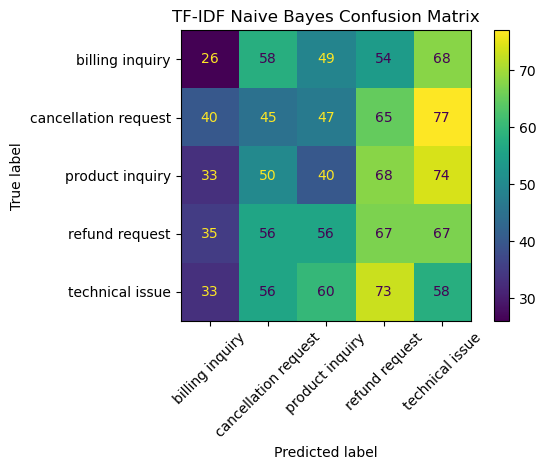

In [27]:
# Create the confusion matrix
cm_tfidf = confusion_matrix(y_test, tfidf_predictions)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tfidf,
    display_labels=tfidf_model.classes_
)

disp.plot(xticks_rotation=45)

plt.title("TF-IDF Naive Bayes Confusion Matrix")
plt.tight_layout()
plt.show()

## Bag-of-Words Confusion Matrix

In [28]:
# Make predictions using the Bag-of-Words model
bow_predictions = bow_model.predict(X_test_bow)

# Calculate evaluation metrics
bow_accuracy = accuracy_score(y_test, bow_predictions)
bow_precision = precision_score(
    y_test,
    bow_predictions,
    average="weighted"
)
bow_recall = recall_score(
    y_test,
    bow_predictions,
    average="weighted"
)
bow_f1 = f1_score(
    y_test,
    bow_predictions,
    average="weighted"
)

print("Bag-of-Words Naive Bayes Evaluation")
print("-" * 40)
print(f"Accuracy : {bow_accuracy:.4f}")
print(f"Precision: {bow_precision:.4f}")
print(f"Recall   : {bow_recall:.4f}")
print(f"F1 Score : {bow_f1:.4f}")

print("\nClassification Report")
print(classification_report(y_test, bow_predictions))

Bag-of-Words Naive Bayes Evaluation
----------------------------------------
Accuracy : 0.1882
Precision: 0.1869
Recall   : 0.1882
F1 Score : 0.1870

Classification Report
                      precision    recall  f1-score   support

     billing inquiry       0.17      0.14      0.15       255
cancellation request       0.18      0.18      0.18       274
     product inquiry       0.18      0.18      0.18       265
      refund request       0.22      0.25      0.23       281
     technical issue       0.18      0.19      0.19       280

            accuracy                           0.19      1355
           macro avg       0.19      0.19      0.19      1355
        weighted avg       0.19      0.19      0.19      1355



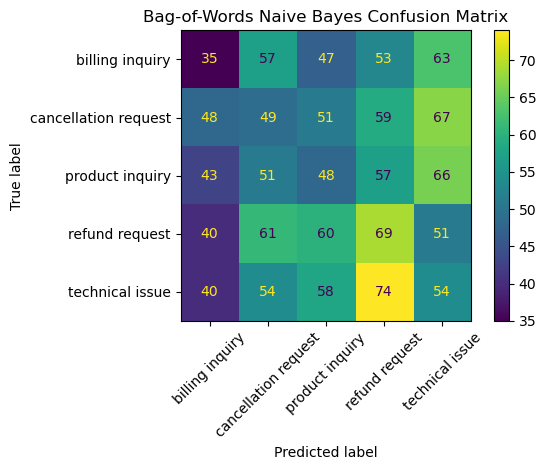

In [29]:
# Create the confusion matrix
cm_bow = confusion_matrix(y_test, bow_predictions)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_bow,
    display_labels=bow_model.classes_
)

disp.plot(xticks_rotation=45)

plt.title("Bag-of-Words Naive Bayes Confusion Matrix")
plt.tight_layout()
plt.show()

## Model Comparison

In [30]:
# Create a comparison table
comparison_df = pd.DataFrame({
    "Model": ["TF-IDF Naive Bayes", "Bag-of-Words Naive Bayes"],
    "Accuracy": [tfidf_accuracy, bow_accuracy],
    "Precision": [tfidf_precision, bow_precision],
    "Recall": [tfidf_recall, bow_recall],
    "F1 Score": [tfidf_f1, bow_f1]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,TF-IDF Naive Bayes,0.174170,0.172012,0.174170,0.171337
1,Bag-of-Words Naive Bayes,0.188192,0.186896,0.188192,0.187034


## Conclusion

Both Naive Bayes models were evaluated using Accuracy, Precision, Recall, and F1-score. The comparison table shows the performance of each approach. Based on the evaluation metrics and confusion matrices, the better-performing model can be selected for classifying customer support tickets. This notebook demonstrates how trained NLP models can be evaluated using multiple performance measures.